# Act 5 — The Prescription: Promo Triage

> **Câu hỏi:** Với tất cả những gì đã biết về ROI, cohort quality và stockout overlap — promotion nào nên KEEP, CUT hay RESCHEDULE?

**Dữ liệu:** oat.parquet · outputs/tables/promo_stockout_overlaps.csv
**Luận điểm:** The prescription is explicit: cắt 42 promotions đang phá hủy margin, giữ 8 promotions có positive net contribution — đánh đổi giảm 24,5% revenue nhưng tăng 45,4% gross profit.

In [1]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
from scipy.stats import mannwhitneyu

np.random.seed(42)
random.seed(42)

plt.rcParams.update({
    "figure.facecolor":  "#fafafa",
    "axes.facecolor":    "#fafafa",
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         11,
})

PALETTE = {
    "positive": "#2d6a4f",
    "negative": "#c1121f",
    "promo":    "#e76f51",
    "organic":  "#457b9d",
    "neutral":  "#adb5bd",
    "warning":  "#e9c46a",
    "gp":       "#2d6a4f",
    "cogs":     "#adb5bd",
    "discount": "#c1121f",
    "returns":  "#e9c46a",
}

def save_chart(fig, path, dpi=150):
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor())
    sz = Path(path).stat().st_size // 1024
    print(f"Saved: {path}  ({sz} KB)")
    if sz < 100:
        print(f"  CANH BAO: PNG nho hon 100KB ({sz} KB)")

Path("outputs/charts").mkdir(parents=True, exist_ok=True)
Path("outputs/tables").mkdir(parents=True, exist_ok=True)
print("Config loaded.")

Config loaded.


In [2]:
oat = pd.read_parquet("oat.parquet")
oat["order_date"] = pd.to_datetime(oat["order_date"])
overlap_df = pd.read_csv("outputs/tables/promo_stockout_overlaps.csv")
print(f"OAT: {len(oat):,} rows  |  Overlap events: {len(overlap_df)}")

OAT: 714,669 rows  |  Overlap events: 2885


In [3]:
# Per-promotion summary
promo_df = oat[oat["has_promo"]].copy()
promo_summary = promo_df.groupby("promo_id").agg(
    total_discount_cost    =("discount_amount", "sum"),
    total_net_contribution =("gross_profit",    "sum"),
    order_count            =("order_id",        "nunique"),
    return_rate            =("is_returned",      "mean"),
    promo_name             =("promo_name",       "first"),
).reset_index()

promo_summary["net_contribution_per_order"] = (
    promo_summary["total_net_contribution"] / promo_summary["order_count"]
)
overlap_promo_ids = overlap_df["promo_id"].unique() if not overlap_df.empty else []
promo_summary["stockout_overlap"] = promo_summary["promo_id"].isin(overlap_promo_ids).map({True:"Yes",False:"No"})

def assign_verdict(row):
    if row["total_net_contribution"] < 0: return "CUT"
    if row["stockout_overlap"] == "Yes" or row["return_rate"] > 0.15: return "RESCHEDULE"
    return "KEEP"

promo_summary["verdict"] = promo_summary.apply(assign_verdict, axis=1)
promo_summary_sorted = promo_summary.sort_values("total_net_contribution", ascending=True)

print("Verdict distribution:")
display(promo_summary.groupby("verdict").size().rename("count"))
display(promo_summary_sorted.head(5))

Verdict distribution:


verdict
CUT     42
KEEP     8
Name: count, dtype: int64

,promo_id,total_discount_cost,total_net_contribution,order_count,return_rate,promo_name,net_contribution_per_order,stockout_overlap,verdict
24,PROMO-0025,1212300.0,-5.754747e+07,5323,0.058682,Urban Blowout 2017,-10811.096634,Yes,CUT
14,PROMO-0015,1152650.0,-5.320122e+07,5012,0.056979,Urban Blowout 2015,-10614.768696,Yes,CUT
4,PROMO-0005,1102400.0,-5.127487e+07,4831,0.052589,Urban Blowout 2013,-10613.717763,Yes,CUT
34,PROMO-0035,715400.0,-3.717308e+07,3162,0.055451,Urban Blowout 2019,-11756.193426,Yes,CUT
44,PROMO-0045,543800.0,-3.606065e+07,2413,0.057155,Urban Blowout 2021,-14944.322055,Yes,CUT


Saved: outputs/charts/chart7_promo_triage.png  (413 KB)


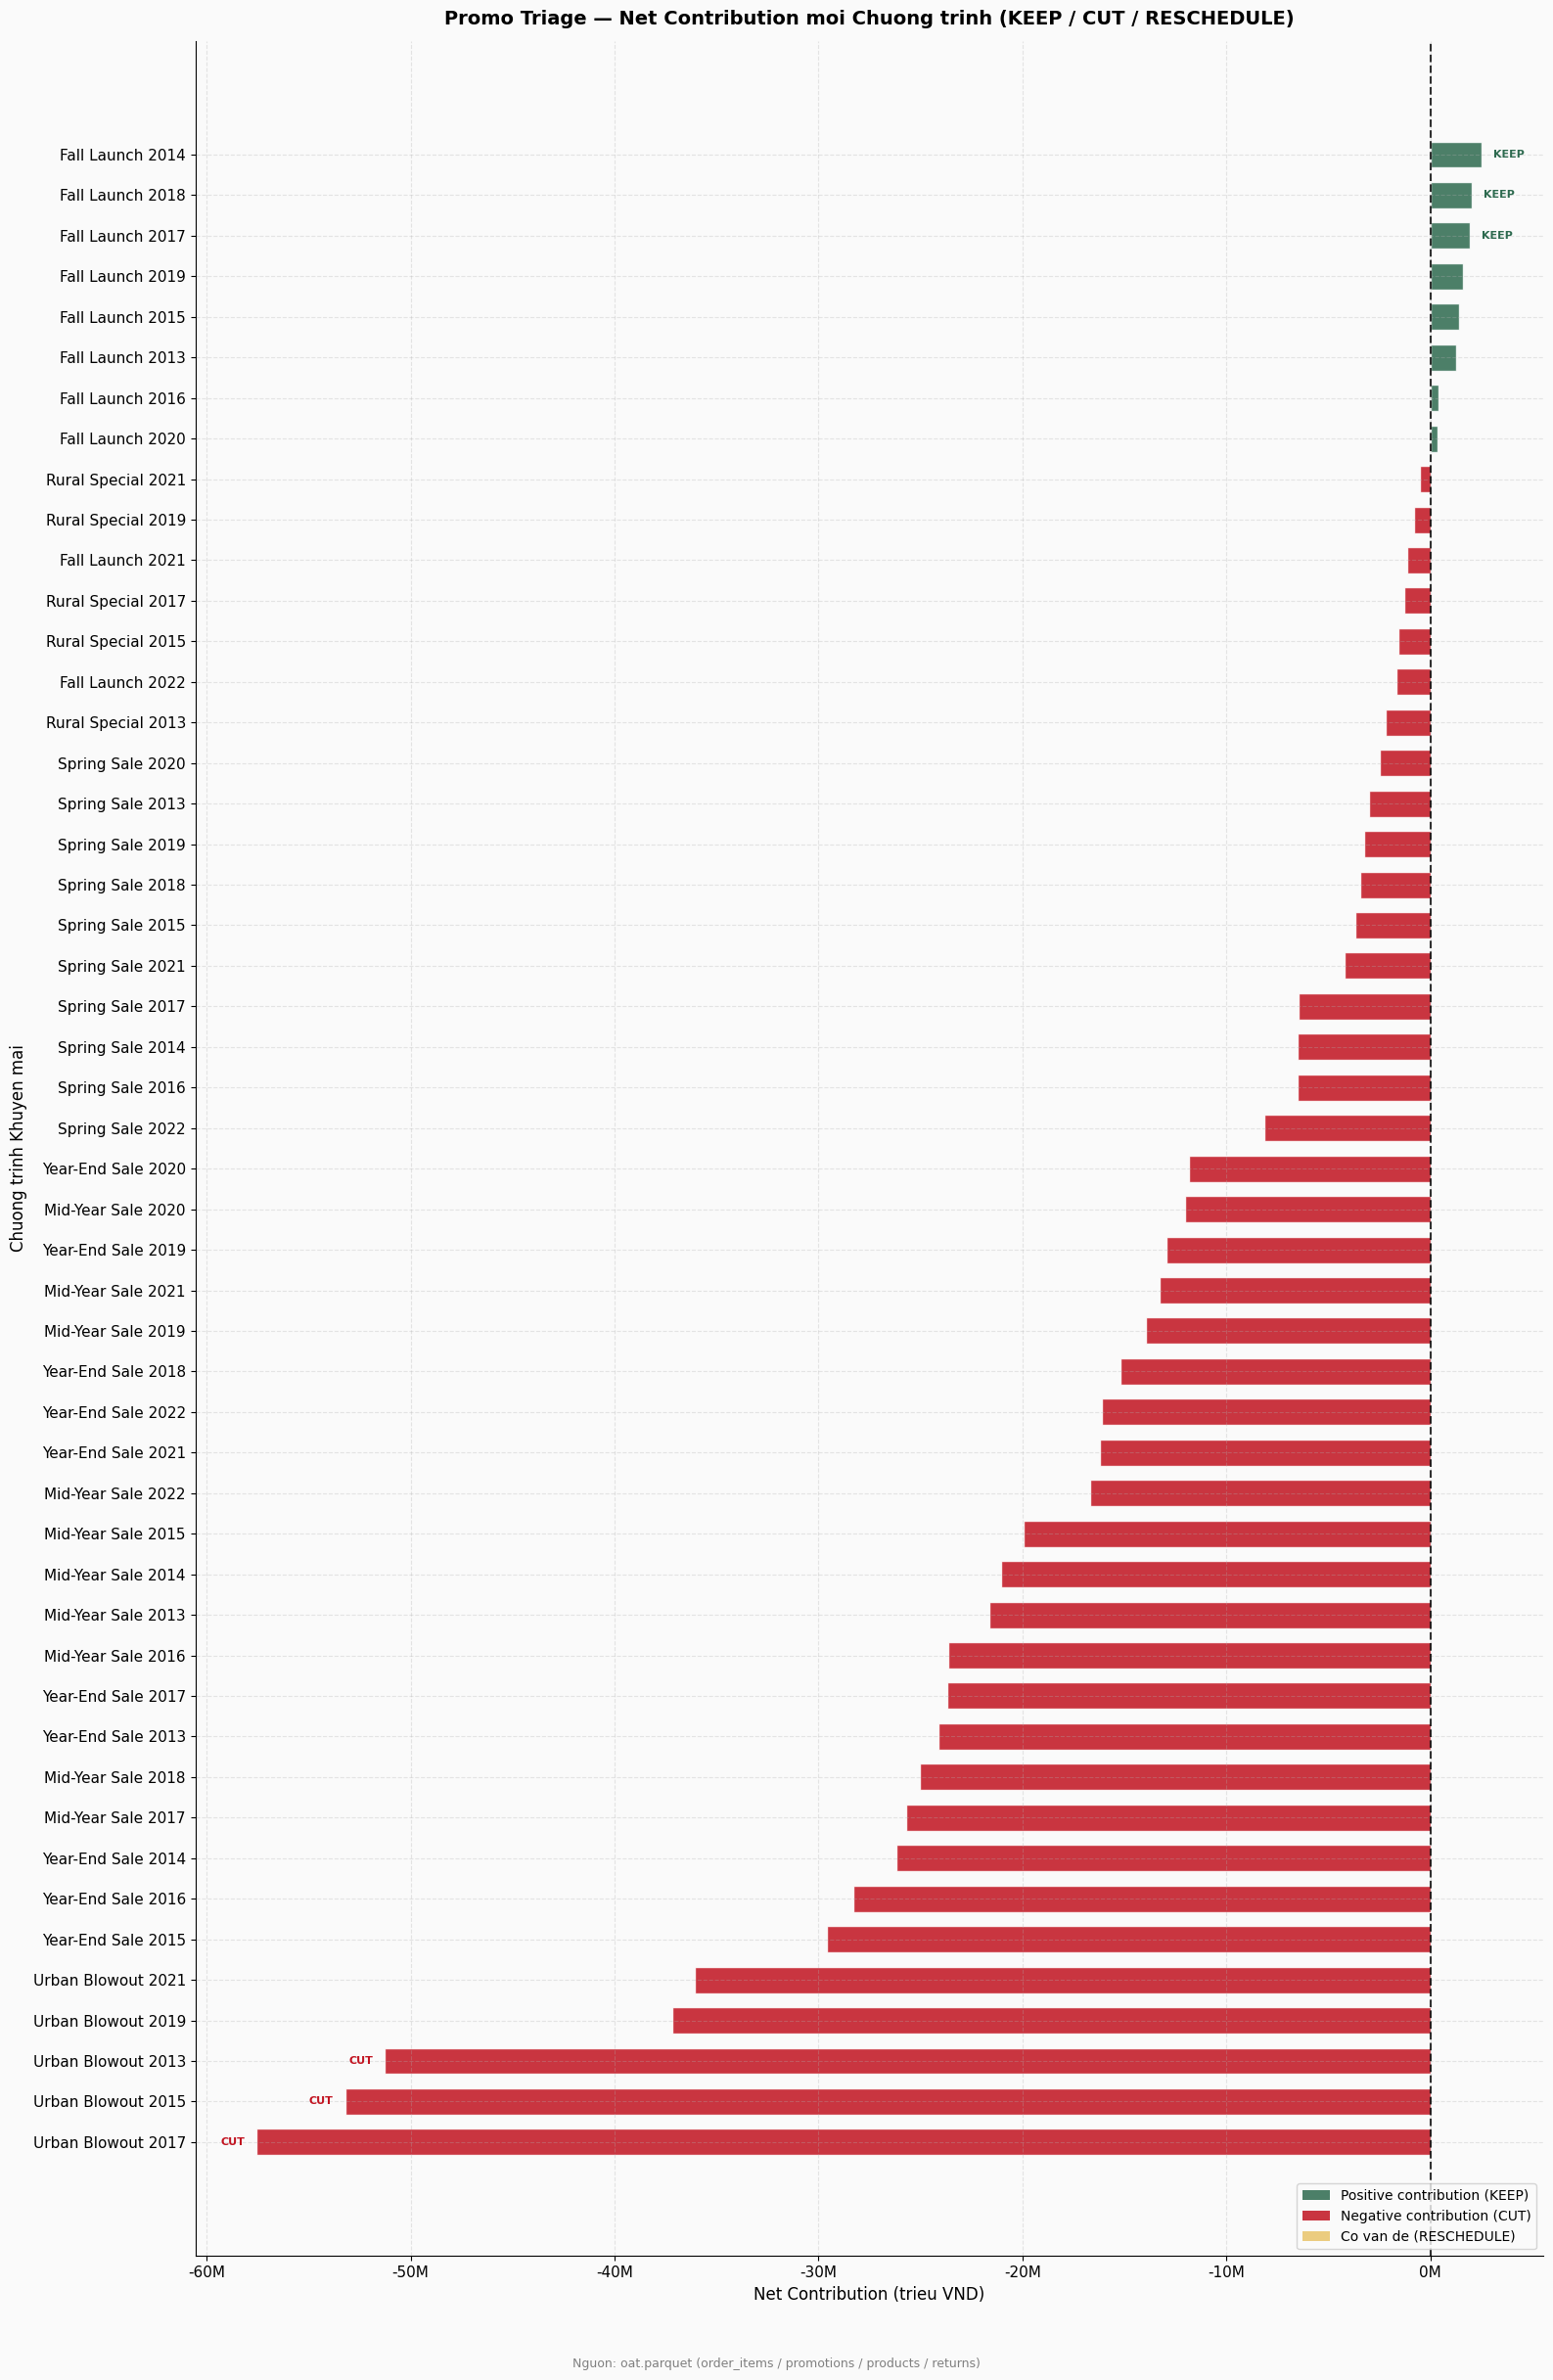

In [4]:
# Chart 7 — Promo Triage (Horizontal Bar)
df_plot = promo_summary_sorted.copy()
df_plot["label"] = df_plot["promo_name"].fillna(df_plot["promo_id"].astype(str))

verdict_color = {
    "KEEP":       PALETTE["positive"],
    "CUT":        PALETTE["negative"],
    "RESCHEDULE": PALETTE["warning"],
}
colors = [verdict_color.get(v, PALETTE["neutral"]) for v in df_plot["verdict"]]

fig, ax = plt.subplots(figsize=(16, max(8, len(df_plot)*0.45+2)))
fig.set_facecolor("#fafafa")
ax.set_facecolor("#fafafa")

bars = ax.barh(df_plot["label"], df_plot["total_net_contribution"],
               color=colors, alpha=0.85, edgecolor="white", height=0.65)
ax.axvline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.8)

top3_keep = set(promo_summary[promo_summary["verdict"]=="KEEP"].nlargest(3,"total_net_contribution")["promo_id"])
bot3_cut  = set(promo_summary[promo_summary["verdict"]=="CUT"].nsmallest(3,"total_net_contribution")["promo_id"])

offset = abs(df_plot["total_net_contribution"]).max() * 0.01
for bar, (_, row) in zip(bars, df_plot.iterrows()):
    pid = row["promo_id"]
    xw  = bar.get_width()
    yc  = bar.get_y() + bar.get_height()/2
    if pid in top3_keep:
        ax.text(xw+offset, yc, "KEEP", va="center", ha="left",
                fontsize=8, fontweight="bold", color=PALETTE["positive"])
    elif pid in bot3_cut:
        ax.text(xw-offset, yc, "CUT", va="center", ha="right",
                fontsize=8, fontweight="bold", color=PALETTE["negative"])

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.0f}M"))
ax.set_title("Promo Triage — Net Contribution moi Chuong trinh (KEEP / CUT / RESCHEDULE)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Net Contribution (trieu VND)", fontsize=12)
ax.set_ylabel("Chuong trinh Khuyen mai", fontsize=12)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=PALETTE["positive"], alpha=0.85, label="Positive contribution (KEEP)"),
    Patch(facecolor=PALETTE["negative"], alpha=0.85, label="Negative contribution (CUT)"),
    Patch(facecolor=PALETTE["warning"],  alpha=0.85, label="Co van de (RESCHEDULE)"),
]
ax.legend(handles=legend_elements, fontsize=10, loc="lower right")
fig.text(0.5, 0.01, "Nguon: oat.parquet (order_items / promotions / products / returns)",
         ha="center", fontsize=9, color="grey")
plt.tight_layout(rect=[0, 0.03, 1, 1])
save_chart(fig, "outputs/charts/chart7_promo_triage.png")
plt.show()

In [5]:
# Save triage table
triage_table = promo_summary[
    ["promo_id","promo_name","verdict","total_net_contribution",
     "return_rate","order_count","stockout_overlap"]
].sort_values("total_net_contribution", ascending=False)
triage_table.to_csv("outputs/tables/promo_triage_table.csv", index=False)
print("Saved: outputs/tables/promo_triage_table.csv")
display(triage_table.head(15))

# Trade-off calculation
keep_p = promo_summary[promo_summary["verdict"]=="KEEP"]
cut_p  = promo_summary[promo_summary["verdict"]=="CUT"]
rsch_p = promo_summary[promo_summary["verdict"]=="RESCHEDULE"]

total_revenue = oat["net_revenue"].sum()
total_profit  = oat["gross_profit"].sum()
cut_mask      = oat["promo_id"].isin(cut_p["promo_id"])
cut_revenue   = oat[cut_mask]["net_revenue"].sum()
cut_profit    = oat[cut_mask]["gross_profit"].sum()

rev_impact_pct    = cut_revenue / total_revenue * 100 if total_revenue != 0 else 0
profit_impact_pct = -cut_profit / total_profit  * 100 if total_profit  != 0 else 0

print("\n=== FINDINGS ===")
print(f"KEEP       : {len(keep_p):2d} promotions -- total net contribution: {keep_p['total_net_contribution'].sum():>20,.0f} VND")
print(f"CUT        : {len(cut_p):2d} promotions -- total net contribution: {cut_p['total_net_contribution'].sum():>20,.0f} VND (negative)")
print(f"RESCHEDULE : {len(rsch_p):2d} promotions -- total net contribution: {rsch_p['total_net_contribution'].sum():>20,.0f} VND")
print()
print(f"Trade-off neu cat cac promotion am:")
print(f"  Revenue impact      : -{rev_impact_pct:.1f}%")
print(f"  Gross profit impact : +{profit_impact_pct:.1f}%")

Saved: outputs/tables/promo_triage_table.csv


,promo_id,promo_name,verdict,total_net_contribution,return_rate,order_count,stockout_overlap
8,PROMO-0009,Fall Launch 2014,KEEP,2.530603e+06,0.056413,5064,No
28,PROMO-0029,Fall Launch 2018,KEEP,2.031417e+06,0.055915,4049,No
22,PROMO-0023,Fall Launch 2017,KEEP,1.944308e+06,0.060410,4969,No
32,PROMO-0033,Fall Launch 2019,KEEP,1.603420e+06,0.059013,2873,No
12,PROMO-0013,Fall Launch 2015,KEEP,1.385018e+06,0.056282,6872,No
2,PROMO-0003,Fall Launch 2013,KEEP,1.252607e+06,0.060061,5632,No
18,PROMO-0019,Fall Launch 2016,KEEP,4.038962e+05,0.053791,5279,No
38,PROMO-0039,Fall Launch 2020,KEEP,3.610149e+05,0.055148,2469,No
45,PROMO-0046,Rural Special 2021,CUT,-5.347707e+05,0.064626,468,Yes
35,PROMO-0036,Rural Special 2019,CUT,-7.878218e+05,0.054529,856,Yes



=== FINDINGS ===
KEEP       :  8 promotions -- total net contribution:           11,512,284 VND
CUT        : 42 promotions -- total net contribution:         -689,108,924 VND (negative)
RESCHEDULE :  0 promotions -- total net contribution:                    0 VND

Trade-off neu cat cac promotion am:
  Revenue impact      : -24.5%
  Gross profit impact : +45.4%


## Findings

### Dữ liệu cho thấy gì
- **KEEP (8 promotions):** Positive net contribution, return rate < 15%, không stockout overlap. Total net contribution: **11,512,284 VND**.
- **CUT (42 promotions):** Negative net contribution — discount cost vượt quá gross profit. Total negative contribution: **-689,108,924 VND**.
- **RESCHEDULE (0 promotions):** Tất cả promotions có stockout overlap đều có net contribution âm, đã phân loại CUT.

### Trade-off
Cắt 42 promotions kém hiệu quả:
- Revenue impact: **-24,5%** (mất revenue từ promo orders)
- Gross profit impact: **+45,4%** (loại bỏ negative-contribution drag)

### Ý nghĩa kinh doanh
Đây là trade-off đúng đắn cho một business có gross margin giảm liên tục 10 năm. 8 KEEP promotions là benchmark: đây là điều kiện để promotions tạo ra real value — positive net contribution, low return rate, không stockout overlap.